# (28) GIF: pvae dict elems (save PNG)

**Motivation**: Make $\Phi$ plots, turn to GIF. This notebook saves PNG figs. <br>

In [1]:
# HIDE CODE


import os, sys
from IPython.display import display

# tmp & extras dir
git_dir = os.path.join(os.environ['HOME'], 'Dropbox/git')
extras_dir = os.path.join(git_dir, 'jb-vae/_extras')
fig_base_dir = os.path.join(git_dir, 'jb-vae/figs')
tmp_dir = os.path.join(git_dir, 'jb-vae/tmp')

# GitHub
sys.path.insert(0, os.path.join(git_dir, 'PoissonVAE'))
from analysis.eval import sparse_score
from figures.fighelper import *
from main.train_vae import *

# warnings, tqdm, & style
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
from rich.jupyter import print
%matplotlib inline
set_style()

In [2]:
from base.utils_model import load_model
from figures.imgs import plot_weights, make_grid

project_name = 'pvae-phi-gif'

kws_fig = {
    'transparent': False,
    'bbox_inches': 'tight',
    'dpi': 300,
}

In [3]:
# HIDE CODE


def do_the_plot(weights, checkpoints, idx, display=False):
    nrows = 16
    ncols = int(np.ceil(512 / nrows))

    grids = {}
    for k, w in weights.items():
        grids[k] = make_grid(
            x=w[idx].T.reshape(512, 16, 16),
            grid_size=(nrows, ncols),
            normalize=False,
            method='none',
        )

    fig, axes = create_figure(2, 1, (12, 10))
    
    axes[0].imshow(grids['poisson'], cmap='Greys_r', vmin=0, vmax=1)
    axes[1].imshow(grids['gaussian'], cmap='Greys_r', vmin=0, vmax=1)
    
    axes[0].set_ylabel('Poisson VAE', fontsize=26, labelpad=13)
    axes[1].set_ylabel('Gaussian VAE', fontsize=26, labelpad=13)
    
    tit = r"$\Phi : $" + ' linear decoder weights'
    tit = f"{tit} (epoch # {checkpoints[idx]})"
    fig.suptitle(tit, fontsize=25, y=1.05)

    remove_ticks(axes, False)

    if display:
        plt.show()
    else:
        plt.close()
    return fig

## Load models

In [4]:
model_names = {
    'poisson': 'poisson_uniform_c(-4)_vH16_z-512_fp_nrm-none_<lin|lin>',
    'gaussian': 'gaussian_vH16_z-512_nrm-none_<lin|lin>',
}
fit_names = {
    'poisson': 'gif_mc_b1000-ep3000-lr(0.005)_beta(1:0x0.5)_temp(0.05:lin-0.5)_gr(500)_(2024_11_30,15:27)',
    'gaussian': 'gif_mc_b1000-ep3000-lr(0.005)_beta(1:0x0.5)_gr(500)_(2024_11_30,15:27)',
}

### Load final models

Compute the order: KL form lowest to highset

In [5]:
trainers_final = {
    k: load_model(
        model_names[k],
        fit_names[k],
        checkpoint=-1,
        device='cpu',
    )[0] for k in model_names
}
orders = {
    k: np.argsort(trainers_final[k].validate()[1]['kl_diag'])
    for k, tr in trainers_final.items()
}

In [6]:
f1, _ = trainers_final['poisson'].model.show(order=orders['poisson'], display=False)
f2, _ = trainers_final['gaussian'].model.show(order=orders['gaussian'], display=False)

f1.savefig(pjoin(fig_base_dir, 'phi_poisson.png'), **kws_fig)
f2.savefig(pjoin(fig_base_dir, 'phi_gaussian.png'), **kws_fig)

## Step 0: weights

extract weights

In [6]:
weights = collections.defaultdict(list)
checkpoints = collections.defaultdict(list)

for chkpt in tqdm(range(1, 3000 + 1)):
    for k in model_names:
        # load trainer
        try:
            tr = load_model(
                model_name=model_names[k],
                fit_name=fit_names[k],
                checkpoint=chkpt,
                device='cpu',
            )[0]
            checkpoints[k].append(chkpt)
        except StopIteration:
            continue
        # save weight
        w = tonp(tr.model.fc_dec.weight.data)
        w = w[:, orders[k]]
        weights[k].append(w)

checkpoints = {
    k: np.asarray(v)for k, v
    in checkpoints.items()
}
weights = {
    k: np.stack(v) for
    k, v in weights.items()
}

100%|███████████████████████████████████████| 3000/3000 [02:36<00:00, 19.13it/s]


In [7]:
list(checkpoints['poisson']) == list(checkpoints['gaussian'])

True

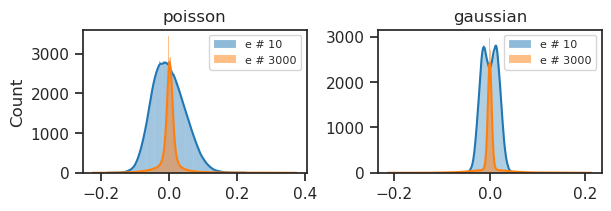

In [8]:
fig, axes = create_figure(1, 2)

for i, (k, w) in enumerate(weights.items()):
    sns.histplot(w[0].ravel(), kde=True, label=f'e # {checkpoints[k][0]}', ax=axes[i])
    sns.histplot(w[-1].ravel(), kde=True, label=f'e # {checkpoints[k][-1]}',  ax=axes[i])
    axes[i].set_title(k)
axes[1].set_ylabel('')
add_legend(axes, fontsize=8)
plt.show()

In [11]:
save_obj(
    obj={'weights': weights, 'checkpoints': checkpoints},
    file_name=f'{project_name}_weights',
    save_dir=tmp_dir,
    mode='npy',
)

[PROGRESS] 'pvae-phi-gif_weights.npy' saved at
/home/hadi/Dropbox/git/jb-vae/tmp


### Load weights

In [4]:
data = pjoin(tmp_dir, f'pvae-phi-gif_weights.npy')
data = np.load(data, allow_pickle=True).item()

weights = data['weights']
checkpoints = data['checkpoints']

assert list(checkpoints['poisson']) == list(checkpoints['gaussian'])
checkpoints = list(checkpoints['poisson'])

In [77]:
### Add random Gaussian
# Corresponding to epoch # 0

In [78]:
# shape = (1, *weights['poisson'].shape[1:])
# w_random = np.random.randn(*shape) * 5e-2

# for k in weights:
#     weights[k] = np.concatenate([
#         w_random, weights[k]])

# checkpoints = [0] + checkpoints

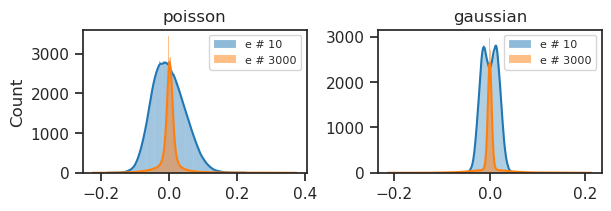

In [5]:
fig, axes = create_figure(1, 2)

for i, (k, w) in enumerate(weights.items()):
    sns.histplot(w[0].ravel(), kde=True, label=f'e # {checkpoints[0]}', ax=axes[i])
    sns.histplot(w[-1].ravel(), kde=True, label=f'e # {checkpoints[-1]}',  ax=axes[i])
    axes[i].set_title(k)
axes[1].set_ylabel('')
add_legend(axes, fontsize=8)
plt.show()

### normalize

In [5]:
kws_imshow = dict(vmin=0, vmax=1, cmap='Greys_r')

In [6]:
weights_normalized = {}

for k, w in weights.items():
    xmin = np.min(w[-1], axis=0, keepdims=True)
    xmax = np.max(w[-1], axis=0, keepdims=True)
    
    xmin = np.expand_dims(xmin, axis=0)
    xmax = np.expand_dims(xmax, axis=0)
    
    numen = w - xmin
    denum = xmax - xmin
    w_nrm = numen / denum

    w_nrm = w_nrm * (
        kws_imshow['vmax'] -
        kws_imshow['vmin']
    ) + kws_imshow['vmin']

    weights_normalized[k] = w_nrm

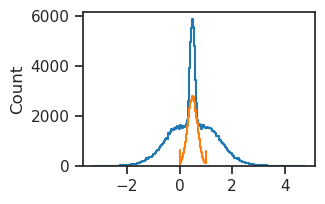

In [8]:
histplot(w_nrm[0].ravel())
histplot(w_nrm[-1].ravel());

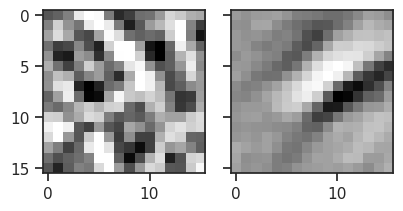

In [9]:
k = 'poisson'
weight_i = 178

fig, axes = create_figure(1, 2, (4, 2), 'all', 'all')
axes[0].imshow(weights_normalized[k][0, :, weight_i].reshape(16, 16), **kws_imshow)
axes[1].imshow(weights_normalized[k][-1, :, weight_i].reshape(16, 16), **kws_imshow)

plt.show()

In [10]:
weights_normalized['poisson'].shape

(300, 256, 512)

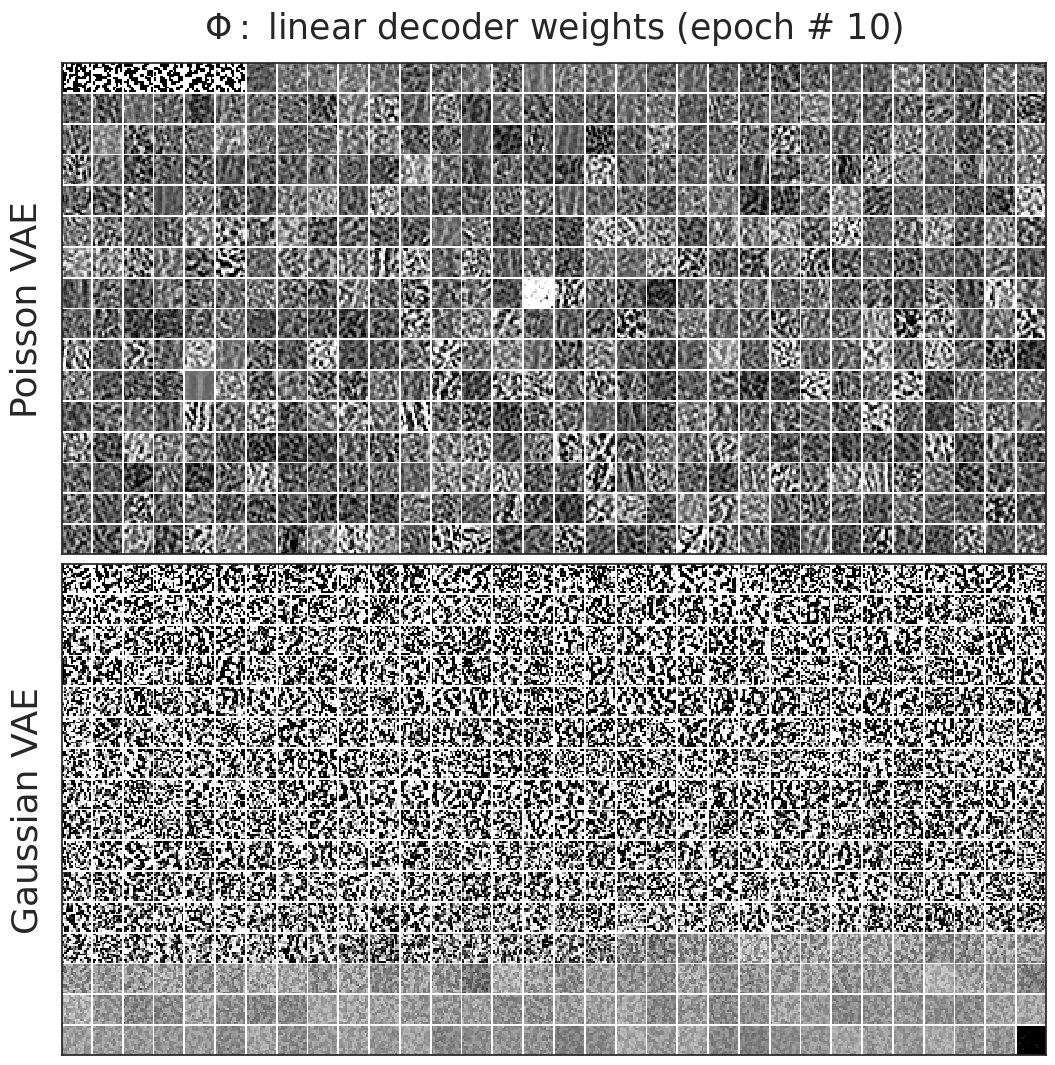

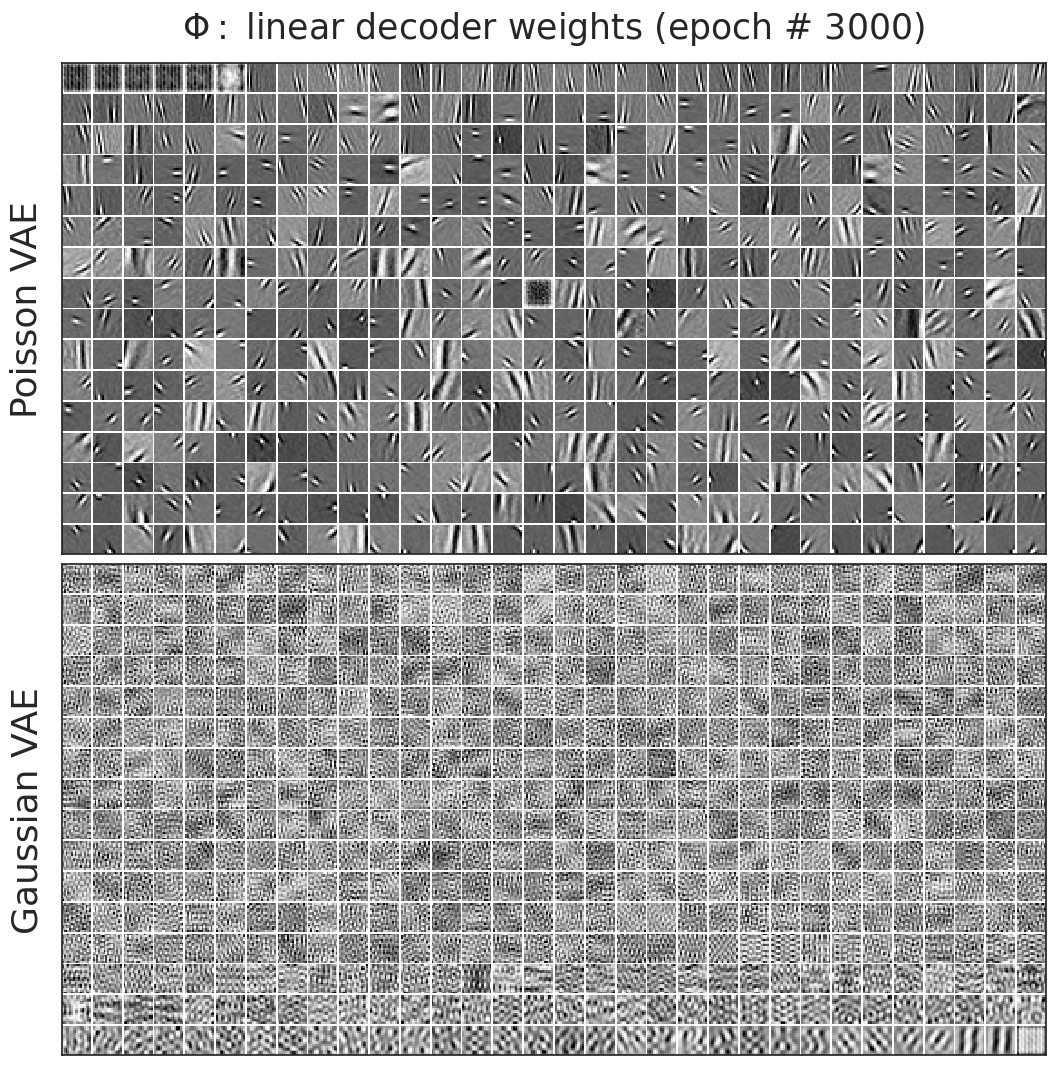

In [11]:
fig = do_the_plot(weights_normalized, checkpoints, 0, display=True)
fig = do_the_plot(weights_normalized, checkpoints, -1, display=True)

## Step 1: PNG

save plots

In [7]:
anim_dir = pjoin(fig_base_dir, 'animation')
os.makedirs(anim_dir, exist_ok=True)
print(os.listdir(anim_dir))

[
    'material',
    'mnist-to-imgnet.mp4',
    'pvae-phi-gif_dpi-600_WithoutInitialWait.mp4',
    'output_video.mp4',
    'mnist-to-imgnet_dpi-140.mp4',
    'mnist-to-imgnet_dpi-300.mp4',
    'mnist-to-imgnet_dpi-150.mp4',
    'pvae-phi-gif_dpi-600.gif'
]

In [8]:
project_name = 'pvae-phi-gif'

### dpi = 300

In [9]:
dpi = 300
kws_fig['dpi'] = dpi

print(kws_fig)

{'transparent': False, 'bbox_inches': 'tight', 'dpi': 300}

In [10]:
fig_dir = pjoin(anim_dir, 'material', f'{project_name}_dpi-{dpi}')
os.makedirs(fig_dir, exist_ok=True)

print(fig_dir)
os.listdir(fig_dir)

/home/hadi/Dropbox/git/jb-vae/figs/animation/material/pvae-phi-gif_dpi-300

[]

In [11]:
for idx, chkpt in tqdm(enumerate(checkpoints), total=len(checkpoints)):
    fig_name = pjoin(fig_dir, f'{project_name}_t={chkpt}.png')
    fig = do_the_plot(weights_normalized, checkpoints, idx, display=False)
    fig.savefig(fig_name, **kws_fig)

100%|█████████████████████████████████████████| 300/300 [05:30<00:00,  1.10s/it]


### dpi = 600

In [12]:
dpi = 600
kws_fig['dpi'] = dpi

print(kws_fig)

{'transparent': False, 'bbox_inches': 'tight', 'dpi': 600}

In [13]:
fig_dir = pjoin(anim_dir, 'material', f'{project_name}_dpi-{dpi}')
os.makedirs(fig_dir, exist_ok=True)

print(fig_dir)
os.listdir(fig_dir)

/home/hadi/Dropbox/git/jb-vae/figs/animation/material/pvae-phi-gif_dpi-600

[]

In [14]:
for idx, chkpt in tqdm(enumerate(checkpoints), total=len(checkpoints)):
    fig_name = pjoin(fig_dir, f'{project_name}_t={chkpt}.png')
    fig = do_the_plot(weights_normalized, checkpoints, idx, display=False)
    fig.savefig(fig_name, **kws_fig)

100%|█████████████████████████████████████████| 300/300 [20:21<00:00,  4.07s/it]


## Save plots across checkpoints (OLD)

In [5]:
# HIDE CODE


def combine_imshow_figs(ax1, ax2, chkpt, display=False):
    
    im1_data = ax1.images[0].get_array()
    im2_data = ax2.images[0].get_array()
    
    cmap1 = ax1.images[0].get_cmap()
    cmap2 = ax2.images[0].get_cmap()
    
    norm1 = ax1.images[0].norm
    norm2 = ax2.images[0].norm
    
    # Create a new figure
    fig, axes = create_figure(2, 1, (16, 14), 'all')
    
    im1 = axes[0].imshow(im1_data, cmap=cmap1, norm=norm1)
    im2 = axes[1].imshow(im2_data, cmap=cmap2, norm=norm2)

    axes[0].set_title(ax1.get_title())
    axes[0].set_xlabel(ax1.get_xlabel())
    axes[0].set_ylabel(ax1.get_ylabel())

    axes[1].set_title(ax2.get_title())
    axes[1].set_xlabel(ax2.get_xlabel())
    axes[1].set_ylabel(ax2.get_ylabel())

    axes[0].set_ylabel('Poisson VAE', fontsize=27, labelpad=15)
    axes[1].set_ylabel('Gaussian VAE', fontsize=27, labelpad=15)

    tit = r"$\Phi : $" + ' linear decoder weights'
    tit = f"{tit} (epoch # {chkpt})"
    fig.suptitle(tit, fontsize=25, y=1.045)

    remove_ticks(axes, False)

    if display:
        plt.show()
    else:
        plt.close()
    return fig, axes

### Test one plot

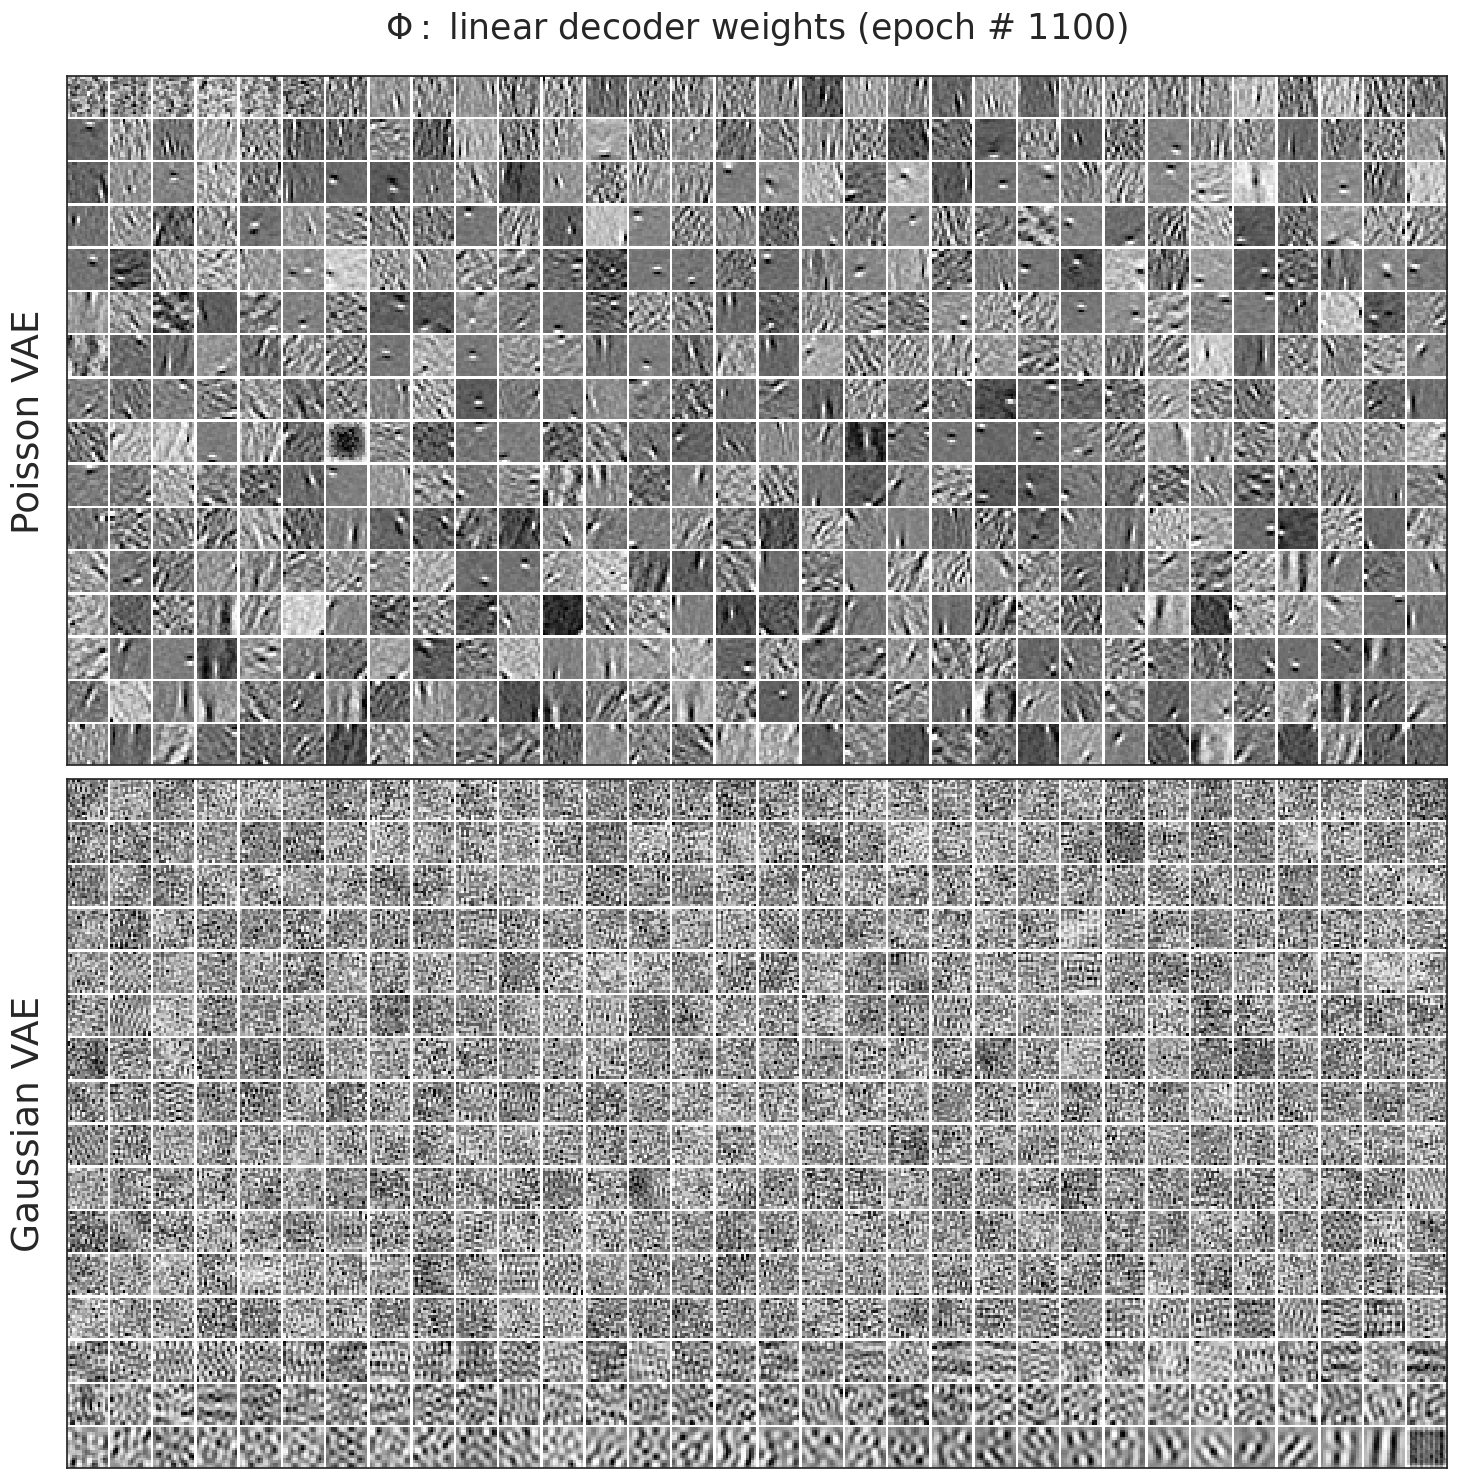

In [6]:
for chkpt in range(1, 3000 + 1):
    if chkpt != 1100:
        continue
    trainers = {
        k: load_model(
            model_names[k],
            fit_names[k],
            checkpoint=chkpt,
            device='cpu',
        )[0] for k in model_names
    }
    f1, ax1 = trainers['poisson'].model.show(order=orders['poisson'], display=False)
    f2, ax2 = trainers['gaussian'].model.show(order=orders['gaussian'], display=False)
    fig, _ = combine_imshow_figs(ax1, ax2, chkpt, display=True)
    break